# Energy Comparison Analysis

This notebook analyzes `energies_comparison.xlsx` with parity plots and energy-vs-system plots.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Consistent and readable plotting style
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (9, 7),
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 22,
    'ytick.labelsize': 22,
    'legend.fontsize': 22,
    'lines.linewidth': 2.2,
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'font.size': 22,
})

DATA_PATH = 'energies_comparison.xlsx'
SAVE_FIGURES = True  # set False to disable saving
FIG_DIR = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)


def normalize_columns(df, sheet_name):
    out = df.copy()

    # Remove unit suffixes and duplicate markers, e.g. "RPBE (eV).1" -> "RPBE"
    cleaned = (
        pd.Series(out.columns.astype(str))
        .str.replace(r'\s*\(eV\)', '', regex=True)
        .str.replace(r'\.\d+$', '', regex=True)
        .str.strip()
    )

    # Ensure uniqueness after cleanup
    counts = {}
    unique_cols = []
    for col in cleaned:
        n = counts.get(col, 0)
        unique_cols.append(col if n == 0 else f'{col}__dup{n}')
        counts[col] = n + 1
    out.columns = unique_cols

    # Standardize finetuning sheet where System became first duplicate RPBE column
    if sheet_name == 'adsorption energies finetuning':
        if 'System' not in out.columns:
            rpbe_like = [c for c in out.columns if c.startswith('RPBE')]
            if rpbe_like:
                # Choose non-numeric RPBE-like column as System
                chosen = None
                for c in rpbe_like:
                    if not pd.api.types.is_numeric_dtype(out[c]):
                        chosen = c
                        break
                if chosen is None:
                    chosen = rpbe_like[0]
                out = out.rename(columns={chosen: 'System'})

        # Keep one numeric RPBE column labeled exactly RPBE
        if 'RPBE' not in out.columns:
            rpbe_numeric = [
                c for c in out.columns
                if c.startswith('RPBE') and c != 'System' and pd.api.types.is_numeric_dtype(out[c])
            ]
            if rpbe_numeric:
                out = out.rename(columns={rpbe_numeric[0]: 'RPBE'})

    return out


molecules_df = normalize_columns(pd.read_excel(DATA_PATH, sheet_name='molecules'), 'molecules')
slab_molecules_df = normalize_columns(pd.read_excel(DATA_PATH, sheet_name='slab molecules'), 'slab molecules')
adsorption_df = normalize_columns(pd.read_excel(DATA_PATH, sheet_name='adsorption energies'), 'adsorption energies')
finetune_df = normalize_columns(pd.read_excel(DATA_PATH, sheet_name='adsorption energies finetuning'), 'adsorption energies finetuning')

for name, df in {
    'molecules': molecules_df,
    'slab molecules': slab_molecules_df,
    'adsorption energies': adsorption_df,
    'adsorption energies finetuning': finetune_df,
}.items():
    print(f'{name}: {df.shape} | columns={list(df.columns)}')

molecules: (18, 5) | columns=['System', 'RPBE', 'PBE', 'OC25', 'UMA']
slab molecules: (36, 5) | columns=['System', 'RPBE', 'PBE', 'OC25', 'UMA']
adsorption energies: (35, 6) | columns=['System', 'Molecules', 'RPBE', 'PBE', 'OC25', 'UMA']
adsorption energies finetuning: (8, 4) | columns=['System', 'RPBE', 'OC25', 'UMA']


In [18]:
def metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    return rmse, mae


def _safe_filename(name):
    return ''.join(ch if ch.isalnum() or ch in ('-', '_') else '_' for ch in name).strip('_').lower()


def parity_plot(df, x_col, y_cols, title, save_name=None, save=SAVE_FIGURES):
    fig, ax = plt.subplots(figsize=(8.5, 7.5))

    all_vals = []
    stats_text = []
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']

    for idx, y_col in enumerate(y_cols):
        tmp = df[[x_col, y_col]].dropna()
        ax.scatter(tmp[x_col], tmp[y_col], s=55, alpha=0.82, label=f'{y_col} vs {x_col}', color=colors[idx % len(colors)])
        rmse, mae = metrics(tmp[x_col], tmp[y_col])
        stats_text.append(f'{y_col}: RMSE={rmse:.4f} eV, MAE={mae:.4f} eV')
        all_vals.extend(tmp[x_col].tolist())
        all_vals.extend(tmp[y_col].tolist())

    min_v, max_v = min(all_vals), max(all_vals)
    pad = 0.03 * (max_v - min_v if max_v > min_v else 1)
    ax.plot([min_v - pad, max_v + pad], [min_v - pad, max_v + pad], 'k--', lw=1.8, label='Parity line')

    ax.set_title(title)
    ax.set_xlabel(f'{x_col} energy (eV)')
    ax.set_ylabel('Predicted energy (eV)')
    ax.legend(loc='best')

    fig.text(0.5, 0.02, ' | '.join(stats_text), ha='center', va='bottom', fontsize=11)
    plt.tight_layout(rect=(0, 0.05, 1, 1))

    if save:
        filename = _safe_filename(save_name or title) + '.png'
        fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')

    plt.show()


def infer_molecule_count(df, system_col='System', molecules_col='Molecules'):
    out = df.copy()
    if molecules_col in out.columns:
        out['molecule_count'] = pd.to_numeric(out[molecules_col], errors='coerce')
    else:
        out['molecule_count'] = np.nan

    missing = out['molecule_count'].isna()
    if missing.any():
        text = out.loc[missing, system_col].astype(str)
        heuristic = text.str.count(r'\+') + 1
        heuristic[text.str.contains('2', na=False)] = np.maximum(heuristic[text.str.contains('2', na=False)], 2)
        out.loc[missing, 'molecule_count'] = heuristic

    out['molecule_count'] = out['molecule_count'].fillna(1).astype(int)
    return out


def energies_vs_system(df, energy_cols, title, rotate=90, save_name=None, save=SAVE_FIGURES):
    fig, ax = plt.subplots(figsize=(14, 6.5))
    x = np.arange(len(df))
    for c in energy_cols:
        ax.plot(x, df[c], marker='o', linestyle='-', label=c)

    ax.set_title(title)
    ax.set_xlabel('System')
    ax.set_ylabel('Energy (eV)')
    ax.set_xticks(x)
    ax.set_xticklabels(df['System'], rotation=rotate, ha='right')
    ax.legend(loc='best')
    plt.tight_layout()

    if save:
        filename = _safe_filename(save_name or title) + '.png'
        fig.savefig(FIG_DIR / filename, dpi=300, bbox_inches='tight')

    plt.show()

## 1) Parity plots: molecules and slab+molecules energies

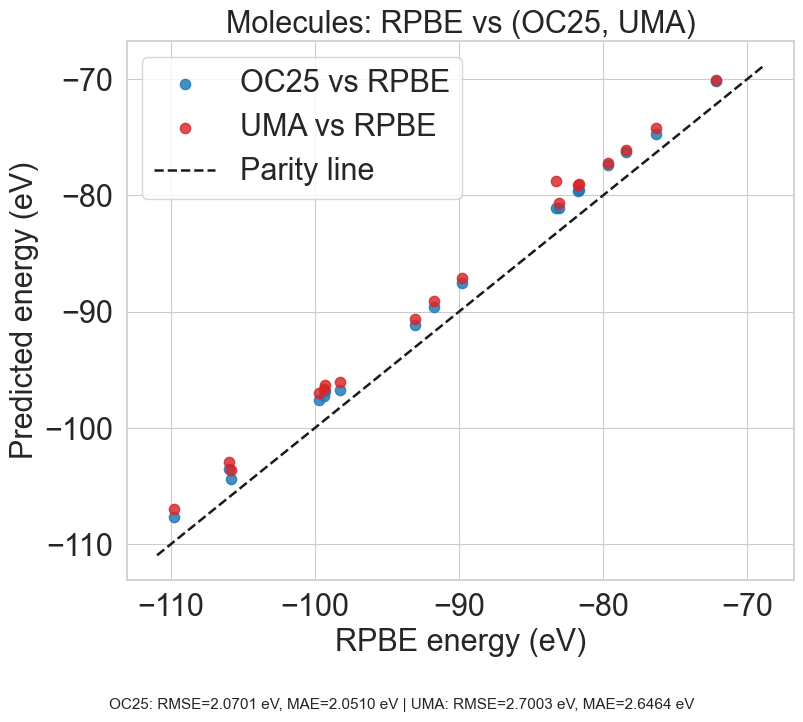

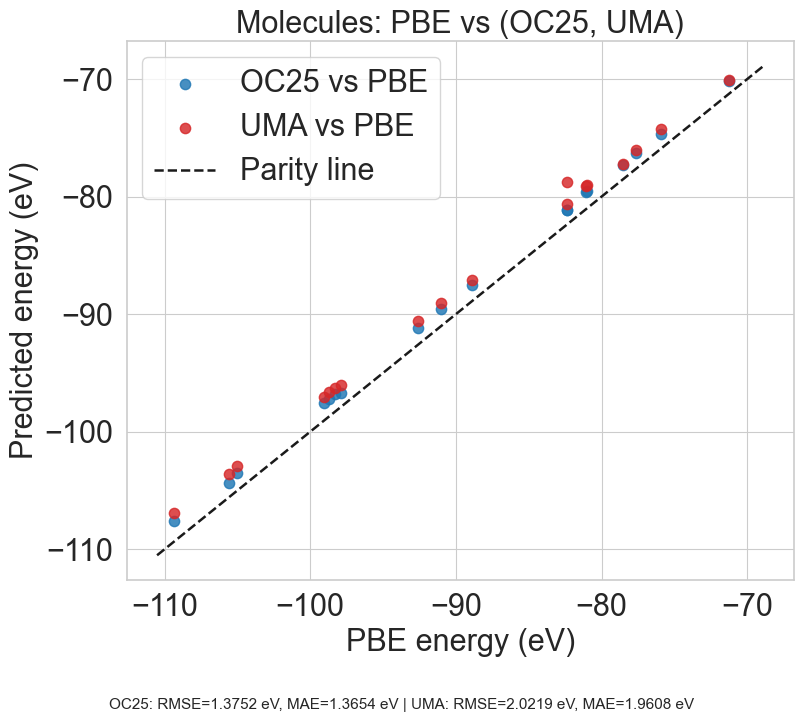

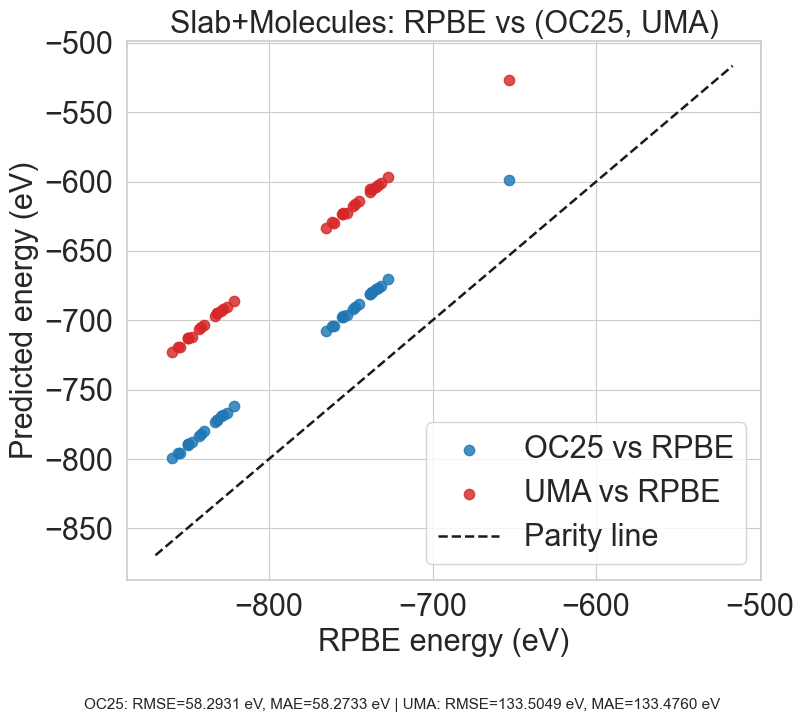

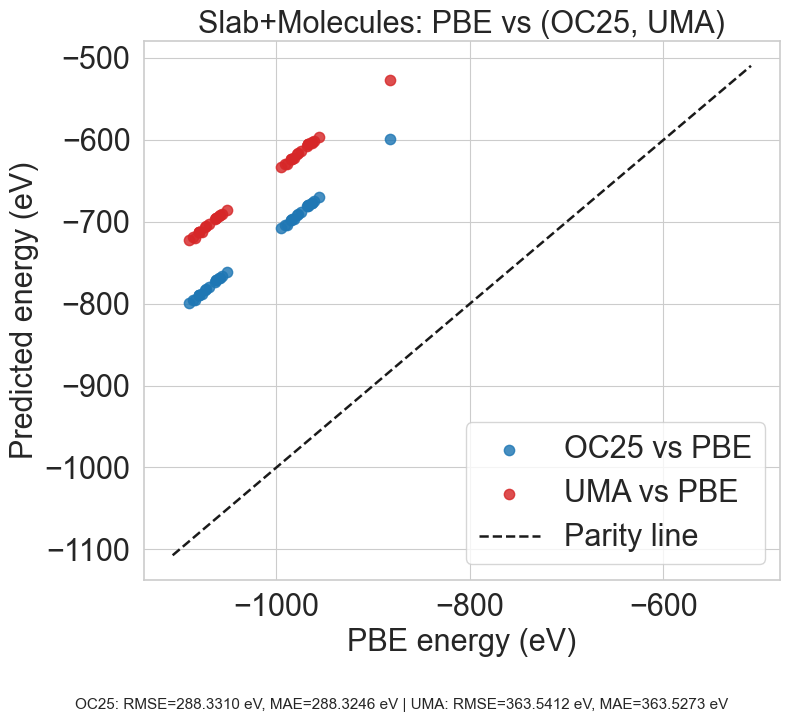

In [19]:
# Molecules parity
parity_plot(
    molecules_df, x_col='RPBE', y_cols=['OC25', 'UMA'],
    title='Molecules: RPBE vs (OC25, UMA)',
    save_name='parity_molecules_rpbe_vs_oc25_uma'
)
parity_plot(
    molecules_df, x_col='PBE', y_cols=['OC25', 'UMA'],
    title='Molecules: PBE vs (OC25, UMA)',
    save_name='parity_molecules_pbe_vs_oc25_uma'
)

# Slab + Molecules parity
parity_plot(
    slab_molecules_df, x_col='RPBE', y_cols=['OC25', 'UMA'],
    title='Slab+Molecules: RPBE vs (OC25, UMA)',
    save_name='parity_slab_molecules_rpbe_vs_oc25_uma'
)
parity_plot(
    slab_molecules_df, x_col='PBE', y_cols=['OC25', 'UMA'],
    title='Slab+Molecules: PBE vs (OC25, UMA)',
    save_name='parity_slab_molecules_pbe_vs_oc25_uma'
)

## 2) Parity plot: adsorption energies

RMSE and MAE are reported for OC25 and UMA against RPBE and PBE.

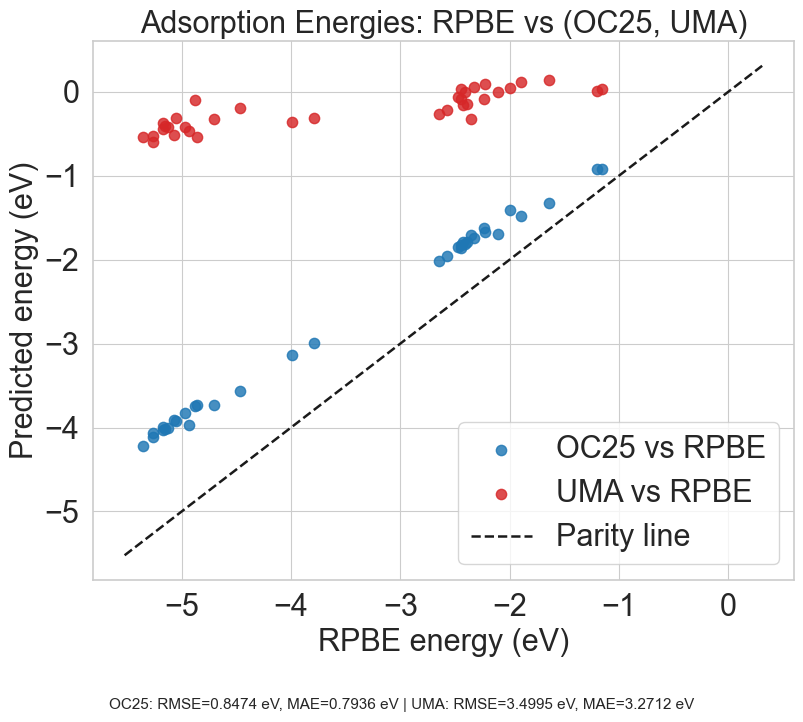

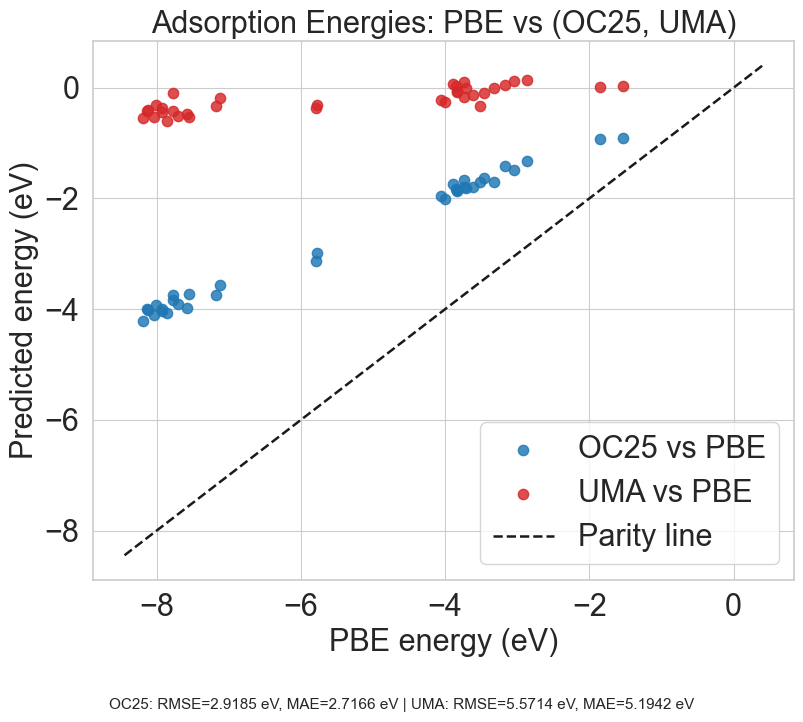

In [20]:
parity_plot(
    adsorption_df, x_col='RPBE', y_cols=['OC25', 'UMA'],
    title='Adsorption Energies: RPBE vs (OC25, UMA)',
    save_name='parity_adsorption_rpbe_vs_oc25_uma'
)
parity_plot(
    adsorption_df, x_col='PBE', y_cols=['OC25', 'UMA'],
    title='Adsorption Energies: PBE vs (OC25, UMA)',
    save_name='parity_adsorption_pbe_vs_oc25_uma'
)

## 3) Adsorption energies finetuning data

- parity plot (x-axis RPBE, y-axis OC25 and DPA_oc25)

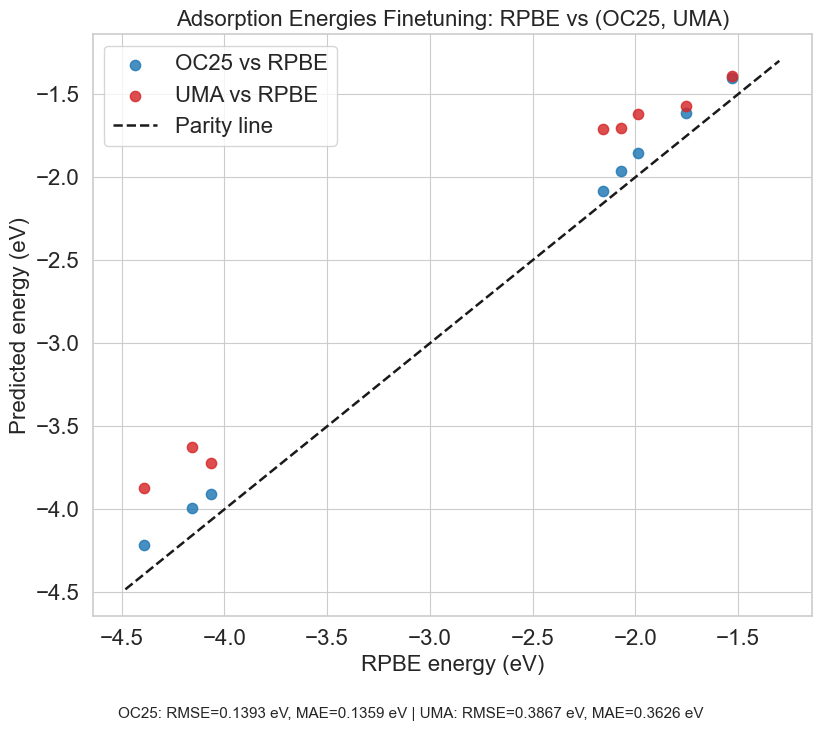

In [25]:
parity_plot(
    finetune_df,
    x_col='RPBE',
    y_cols=['OC25', 'UMA'],
    title='Adsorption Energies Finetuning: RPBE vs (OC25, UMA)',
    save_name='parity_adsorption_finetuning_rpbe_vs_oc25_uma'
)


In [26]:
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize': (9, 7),
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'lines.linewidth': 2.2,
    'axes.linewidth': 1.2,
    'grid.linewidth': 0.8,
    'font.size': 16,
})

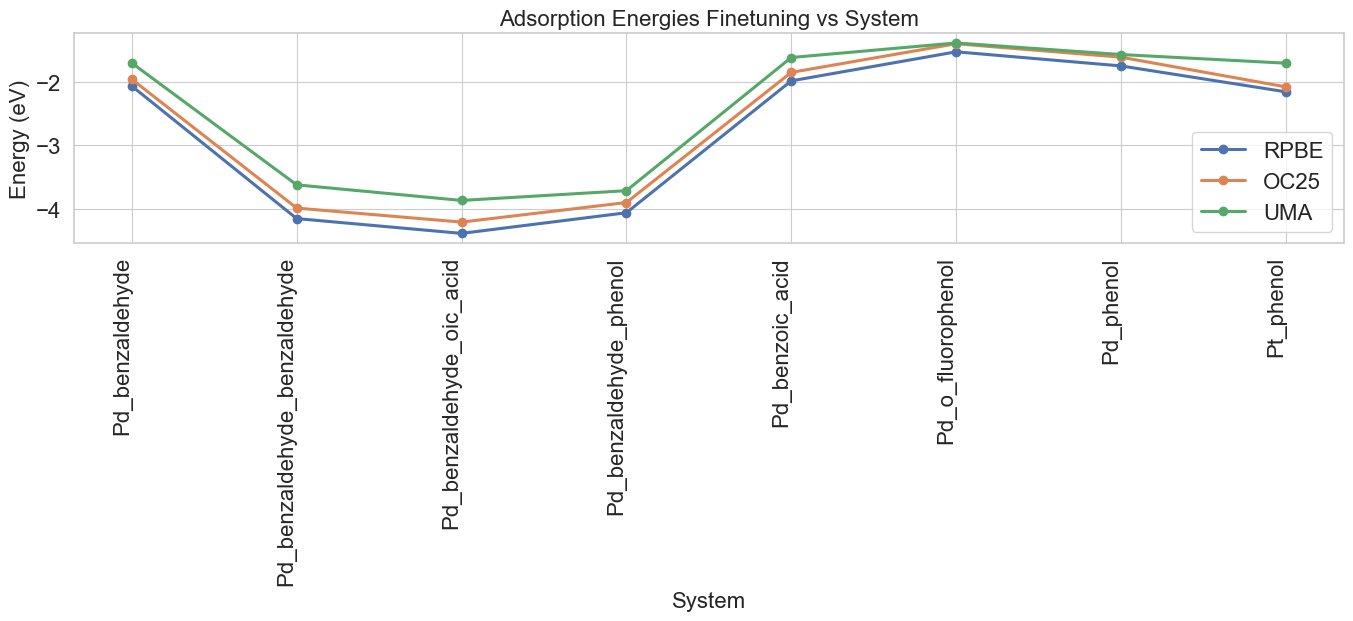

In [27]:

finetune_sorted = finetune_df.sort_values('System').reset_index(drop=True)
energies_vs_system(
    finetune_sorted, ['RPBE', 'OC25', 'UMA'],
    'Adsorption Energies Finetuning vs System',
    save_name='energies_vs_system_adsorption_finetuning'
)

## 4) Energies vs system plots

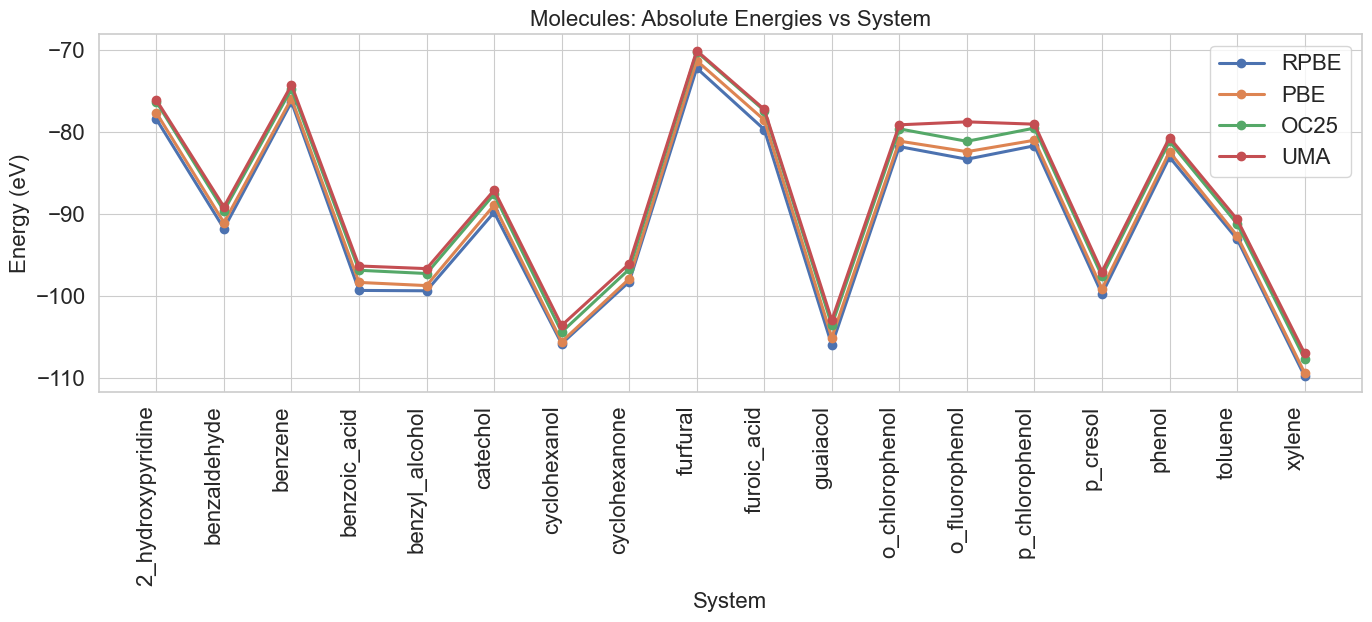

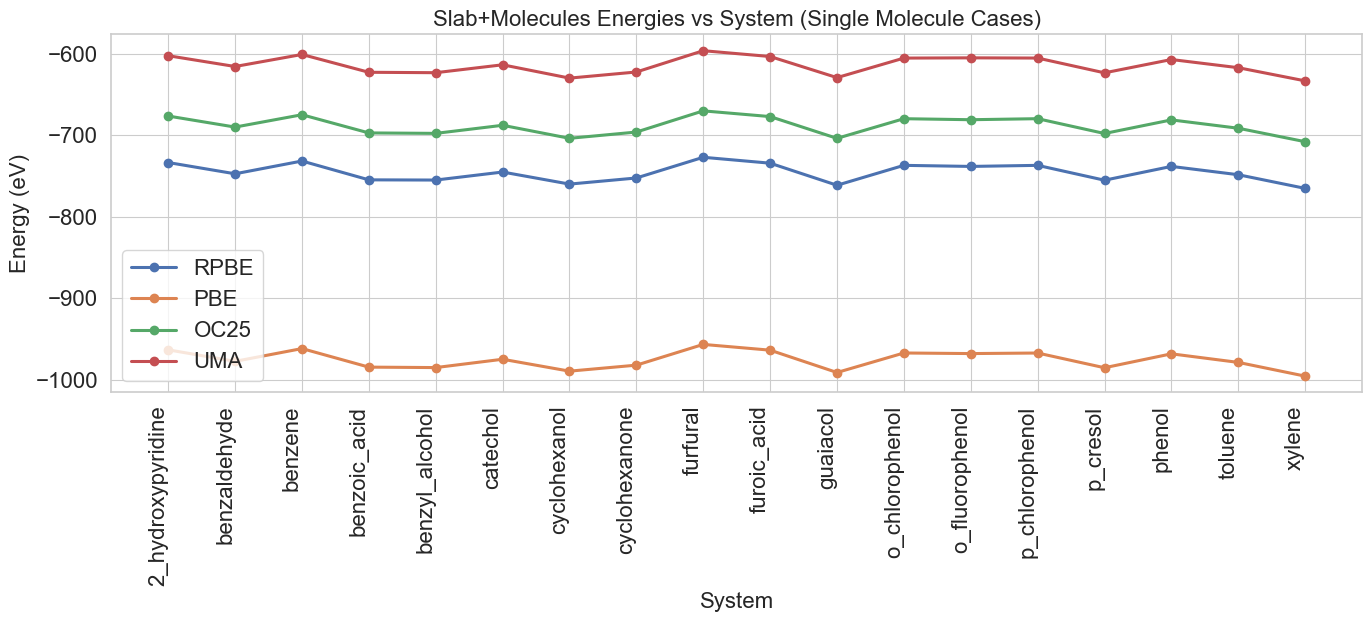

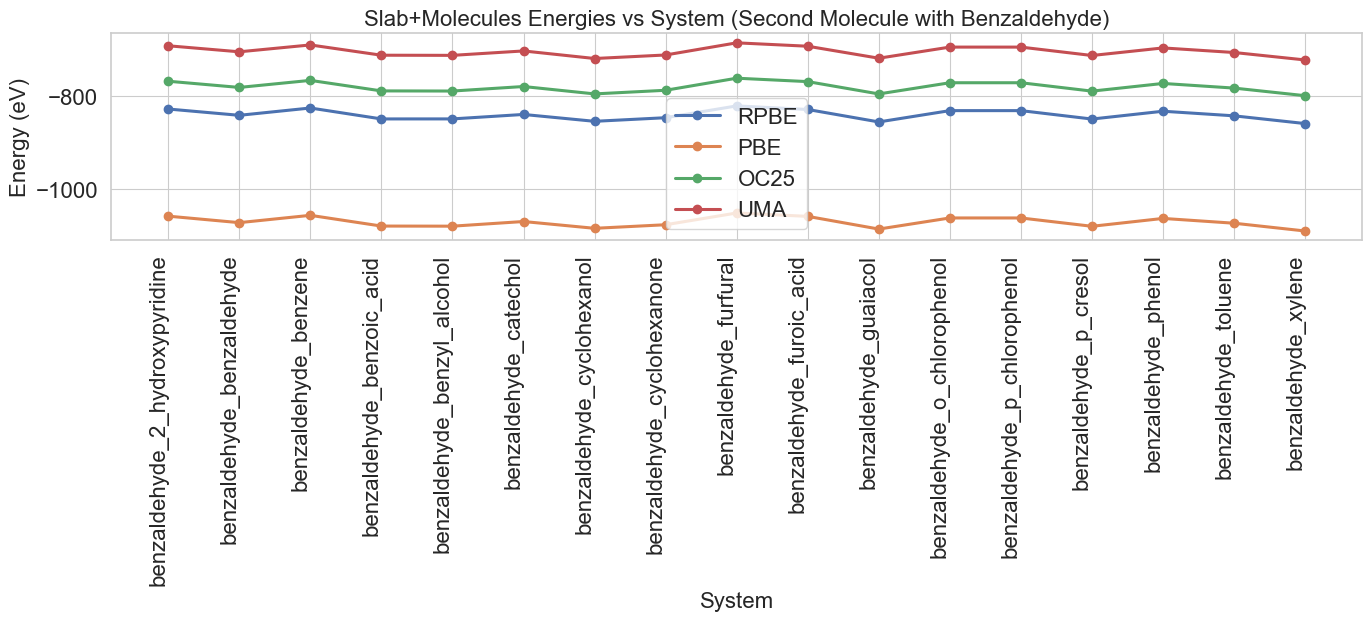

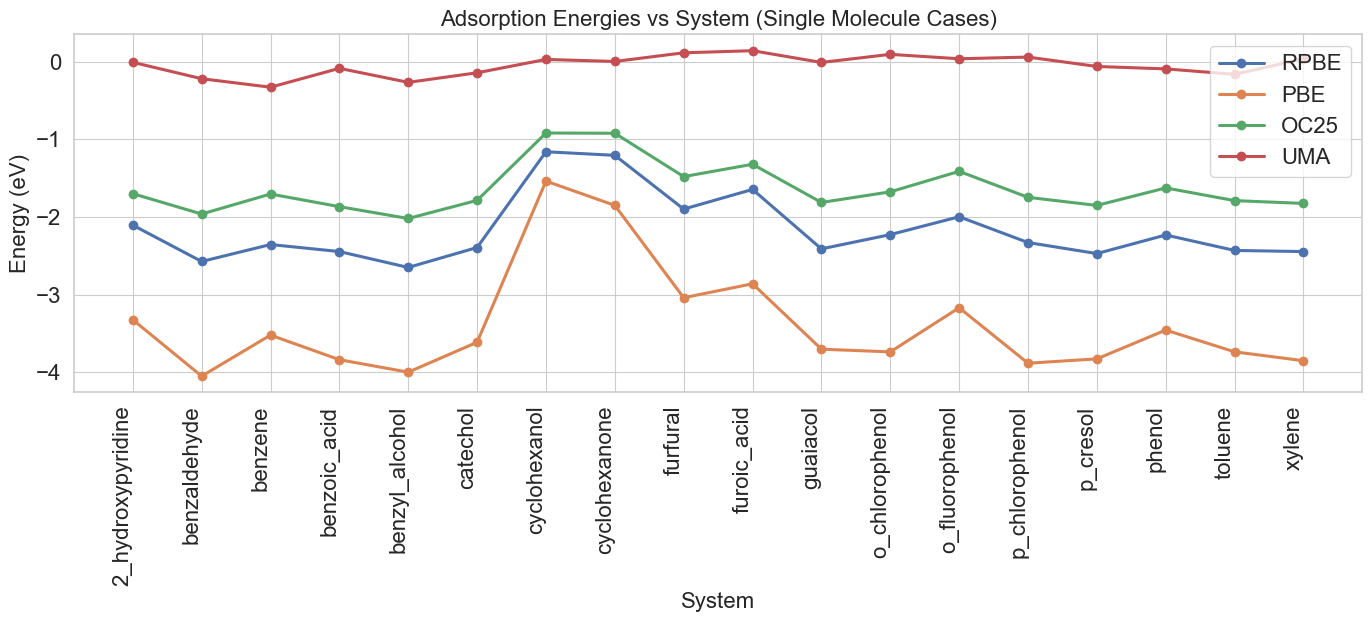

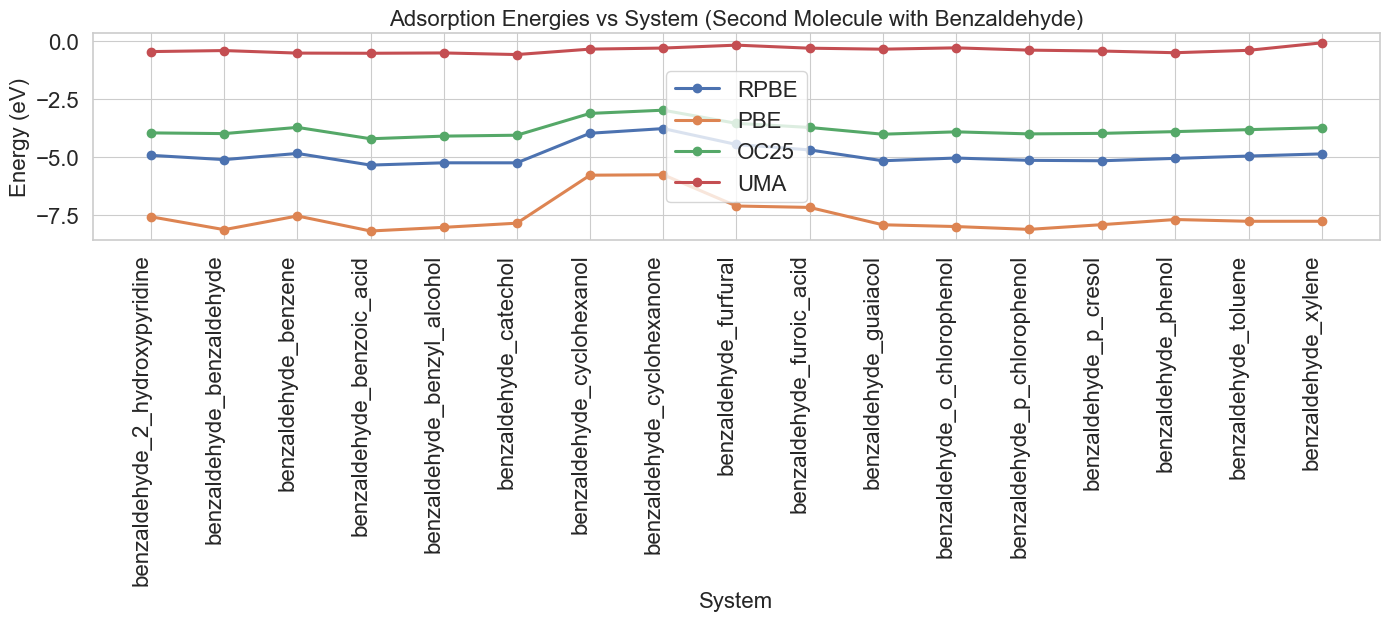

In [28]:
# Molecules absolute energies
molecules_sorted = molecules_df.sort_values('System').reset_index(drop=True)
energies_vs_system(
    molecules_sorted, ['RPBE', 'PBE', 'OC25', 'UMA'],
    'Molecules: Absolute Energies vs System',
    save_name='energies_vs_system_molecules_absolute'
)

# Build system composition flags from adsorption sheet
comp_map = adsorption_df[['System', 'Molecules']].dropna().drop_duplicates().copy()
comp_map['Molecules'] = comp_map['Molecules'].astype(str).str.strip().str.lower()
comp_map['is_single_molecule'] = ~comp_map['Molecules'].str.contains(r'\+', regex=True)
comp_map['is_benzaldehyde_pair'] = comp_map['Molecules'].str.contains('benzaldehyde') & comp_map['Molecules'].str.contains(r'\+', regex=True)

# Add composition flags to slab molecules and adsorption energies
slab_labeled = slab_molecules_df.merge(
    comp_map[['System', 'is_single_molecule', 'is_benzaldehyde_pair']],
    on='System',
    how='left'
)
ads_labeled = adsorption_df.merge(
    comp_map[['System', 'is_single_molecule', 'is_benzaldehyde_pair']],
    on='System',
    how='left'
)

# Slab+molecules split plots
slab_single = slab_labeled[slab_labeled['is_single_molecule'] == True].sort_values('System').reset_index(drop=True)
if len(slab_single) > 0:
    energies_vs_system(
        slab_single,
        ['RPBE', 'PBE', 'OC25', 'UMA'],
        'Slab+Molecules Energies vs System (Single Molecule Cases)',
        save_name='energies_vs_system_slab_single_molecule'
    )

slab_benz_pair = slab_labeled[slab_labeled['is_benzaldehyde_pair'] == True].sort_values('System').reset_index(drop=True)
if len(slab_benz_pair) > 0:
    energies_vs_system(
        slab_benz_pair,
        ['RPBE', 'PBE', 'OC25', 'UMA'],
        'Slab+Molecules Energies vs System (Second Molecule with Benzaldehyde)',
        save_name='energies_vs_system_slab_second_with_benzaldehyde'
    )

# Adsorption split plots
ads_single = ads_labeled[ads_labeled['is_single_molecule'] == True].sort_values('System').reset_index(drop=True)
if len(ads_single) > 0:
    energies_vs_system(
        ads_single,
        ['RPBE', 'PBE', 'OC25', 'UMA'],
        'Adsorption Energies vs System (Single Molecule Cases)',
        save_name='energies_vs_system_adsorption_single_molecule'
    )

ads_benz_pair = ads_labeled[ads_labeled['is_benzaldehyde_pair'] == True].sort_values('System').reset_index(drop=True)
if len(ads_benz_pair) > 0:
    energies_vs_system(
        ads_benz_pair,
        ['RPBE', 'PBE', 'OC25', 'UMA'],
        'Adsorption Energies vs System (Second Molecule with Benzaldehyde)',
        save_name='energies_vs_system_adsorption_second_with_benzaldehyde'
    )